In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [2]:
# Load processed data

X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv")

print("Data Loaded Successfully")

Data Loaded Successfully


In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Recreate Random Forest model
rf_model = RandomForestClassifier(n_estimators=100)

# Reload training data
X_train = pd.read_csv("../data/processed/X_train.csv")
y_train = pd.read_csv("../data/processed/y_train.csv")

# Fix missing values if needed
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_test.median())

# Train again
rf_model.fit(X_train, y_train.values.ravel())

# Predict
y_pred = rf_model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)

print("Random Forest Accuracy:", acc)

Random Forest Accuracy: 0.7920511000709723


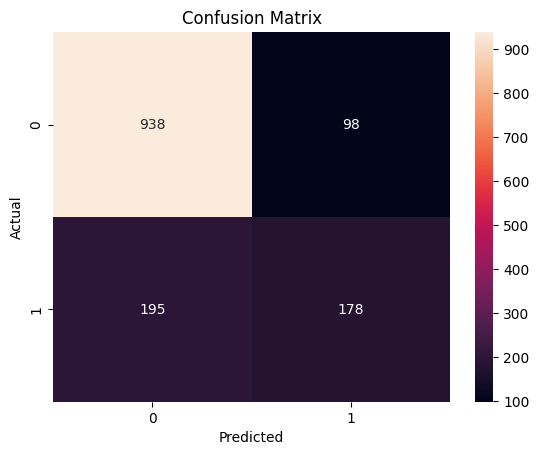

In [4]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [5]:
report = classification_report(y_test, y_pred)

print(report)

              precision    recall  f1-score   support

           0       0.83      0.91      0.86      1036
           1       0.64      0.48      0.55       373

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load training data again
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv")
y_test = pd.read_csv("../data/processed/y_test.csv")

# Fix missing values
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_test.median())

# Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train.values.ravel())
y_pred_log = log_model.predict(X_test)
acc_log = accuracy_score(y_test, y_pred_log)

# Decision Tree
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train, y_train.values.ravel())
y_pred_rf = rf_model.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

# KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train.values.ravel())
y_pred_knn = knn_model.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)

print("Accuracies calculated successfully!")

Accuracies calculated successfully!


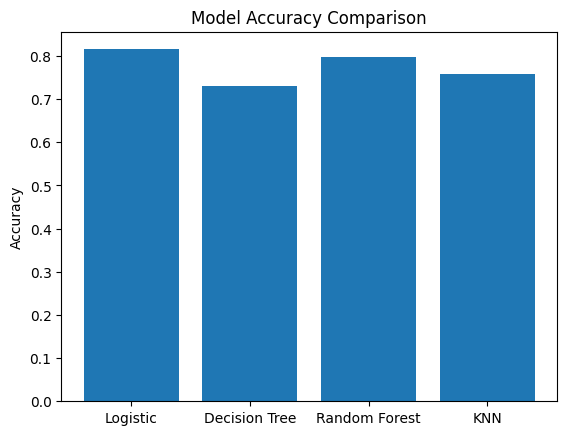

In [8]:
models = ["Logistic", "Decision Tree", "Random Forest", "KNN"]

accuracies = [acc_log, acc_dt, acc_rf, acc_knn]

plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [9]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "KNN"],
    "Accuracy": [acc_log, acc_dt, acc_rf, acc_knn]
})

results

,Model,Accuracy
0,Logistic Regression,0.815472
1,Decision Tree,0.731015
2,Random Forest,0.797019
3,KNN,0.757275


In [12]:
import os

# Create folder if not exists
os.makedirs("../outputs/metrics", exist_ok=True)

# Save file
results.to_csv("../outputs/metrics/model_results.csv", index=False)

print("Results saved successfully!")

Results saved successfully!


In [13]:
import os
print(os.getcwd())

c:\Users\HAMEED COMPUTERS\OneDrive\Documents\pracite\telco_churn_project\notebooks


In [14]:
import os
os.makedirs("../outputs/metrics", exist_ok=True)

In [15]:
results.to_csv("../outputs/metrics/model_results.csv", index=False)

In [16]:
import os

# Create folders safely
os.makedirs("../outputs/metrics", exist_ok=True)

# Save results
results.to_csv("../outputs/metrics/model_results.csv", index=False)

print("Results saved successfully!")

Results saved successfully!


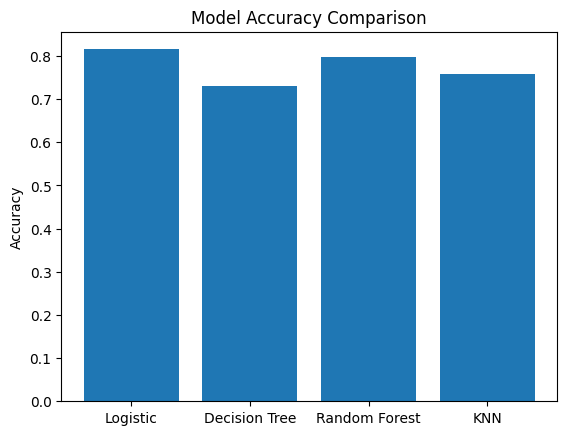

Accuracy graph saved successfully!


In [18]:
import os
import matplotlib.pyplot as plt

# Create figures folder
os.makedirs("../outputs/figures", exist_ok=True)

# Model names
models = ["Logistic", "Decision Tree", "Random Forest", "KNN"]

# Accuracies
accuracies = [acc_log, acc_dt, acc_rf, acc_knn]

# Plot bar chart
plt.figure()
plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

# Save figure
plt.savefig("../outputs/figures/accuracy_comparison.png")

plt.show()

print("Accuracy graph saved successfully!")

In [19]:
import os
import pandas as pd

os.makedirs("../outputs/predictions", exist_ok=True)

pred_df = pd.DataFrame({
    "Actual": y_test.values.ravel(),
    "Predicted": y_pred_rf
})

pred_df.to_csv("../outputs/predictions/predictions.csv", index=False)

print("Predictions saved successfully!")

Predictions saved successfully!
